In [39]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np

file_path = "../data/Sample - Superstore.csv"
df = pd.read_csv(file_path, encoding="Unicode_escape")

 
print(f"Dataset Ölçüsü: {df.shape}")
print(f"Sütun Adları: {df.columns.tolist()}")

Dataset Ölçüsü: (9994, 21)
Sütun Adları: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [40]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [41]:
df.info()
print("Dublikat sətir:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [42]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [43]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

df['days_to_ship'] = (df['Ship Date'] - df['Order Date']).dt.days

print(df[['Order Date', 'Ship Date', 'days_to_ship']].head())
 
print(df['days_to_ship'].describe())

  Order Date  Ship Date  days_to_ship
0 2016-11-08 2016-11-11             3
1 2016-11-08 2016-11-11             3
2 2016-06-12 2016-06-16             4
3 2015-10-11 2015-10-18             7
4 2015-10-11 2015-10-18             7
count    9994.000000
mean        3.958175
std         1.747567
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: days_to_ship, dtype: float64


In [44]:
aggregated_df = df.groupby(['Region', 'Category', 'Sub-Category'], as_index=False).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)
ggregated_df = aggregated_df.sort_values(by=['Region', 'Total_Sales'], ascending=[True, False])
print(aggregated_df)

     Region         Category Sub-Category  Total_Sales  Total_Profit
0   Central        Furniture    Bookcases   24157.1768    -1997.9043
1   Central        Furniture       Chairs   85230.6460     6592.7221
2   Central        Furniture  Furnishings   15254.3700    -3906.2168
3   Central        Furniture       Tables   39154.9710    -3559.6504
4   Central  Office Supplies   Appliances   23582.0330    -2638.6175
..      ...              ...          ...          ...           ...
63     West  Office Supplies     Supplies   18127.1220      626.0465
64     West       Technology  Accessories   61114.1160    16484.5983
65     West       Technology      Copiers   49749.2420    19327.2351
66     West       Technology     Machines   42444.1220     -618.9264
67     West       Technology       Phones   98684.3520     9110.7426

[68 rows x 5 columns]


In [45]:

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [46]:
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Sales', ascending=False)
print(category_summary)

                 Total_Sales  Total_Profit
Category                                  
Technology       836154.0330   145454.9481
Furniture        741999.7953    18451.2728
Office Supplies  719047.0320   122490.8008


In [47]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().reset_index()
top_5 = subcat_profit.nlargest(5, 'Profit')
bottom_5 = subcat_profit.nsmallest(5, 'Profit')

print(top_5.to_string(index=False))

print(bottom_5.to_string(index=False))

Sub-Category     Profit
     Copiers 55617.8249
      Phones 44515.7306
 Accessories 41936.6357
       Paper 34053.5693
     Binders 30221.7633
Sub-Category      Profit
      Tables -17725.4811
   Bookcases  -3472.5560
    Supplies  -1189.0995
   Fasteners    949.5182
    Machines   3384.7569


In [48]:
negative_profit_subcats = df.groupby('Sub-Category')['Profit'].sum()
negative_profit_subcats = negative_profit_subcats[negative_profit_subcats < 0].sort_values()
print("Menfi menfeetde olan sub-kateqoriyalar:")
print(negative_profit_subcats)

Menfi menfeetde olan sub-kateqoriyalar:
Sub-Category
Tables      -17725.4811
Bookcases    -3472.5560
Supplies     -1189.0995
Name: Profit, dtype: float64


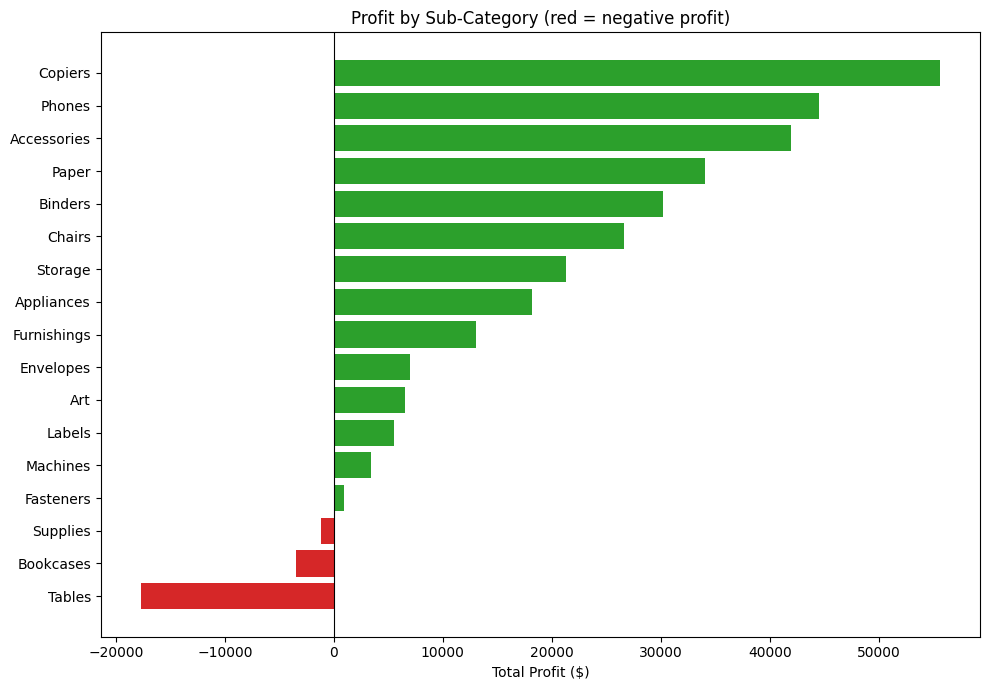

In [49]:
subcat_profit_sorted = subcat_profit.sort_values('Profit')
colors = ['#d62728' if p < 0 else '#2ca02c' for p in subcat_profit_sorted['Profit']]

plt.figure(figsize=(10, 7))
plt.barh(subcat_profit_sorted['Sub-Category'], subcat_profit_sorted['Profit'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Total Profit ($)')
plt.title('Profit by Sub-Category (red = negative profit)')
plt.tight_layout()
plt.show()

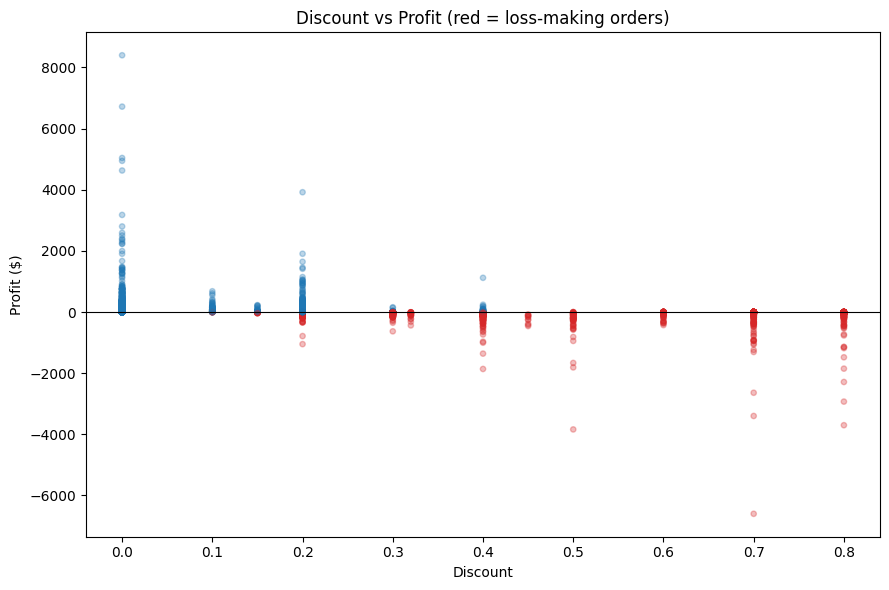

Discount ve Profit arasinda korrelyasiya: -0.219

Endirim > 0.4 olan sifarislerin ortalama menfeeti: -106.71
Endirim <= 0.4 olan sifarislerin ortalama menfeeti: 42.60


In [50]:
plt.figure(figsize=(9, 6))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3, s=15, c=np.where(df['Profit'] < 0, '#d62728', '#1f77b4'))
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Discount')
plt.ylabel('Profit ($)')
plt.title('Discount vs Profit (red = loss-making orders)')
plt.tight_layout()
plt.show()

# Korrelyasiya
corr = df['Discount'].corr(df['Profit'])
print(f"Discount ve Profit arasinda korrelyasiya: {corr:.3f}")

high_discount = df[df['Discount'] > 0.4]
print(f"\nEndirim > 0.4 olan sifarislerin ortalama menfeeti: {high_discount['Profit'].mean():.2f}")
print(f"Endirim <= 0.4 olan sifarislerin ortalama menfeeti: {df[df['Discount'] <= 0.4]['Profit'].mean():.2f}")

In [51]:
df['Order Year'] = df['Order Date'].dt.year
yearly_sales = df.groupby('Order Year')['Sales'].sum()
yearly_growth = yearly_sales.pct_change() * 100

print("Illik satis:")
print(yearly_sales)
print("\nIllik artim (%):")
print(yearly_growth.round(1))

Illik satis:
Order Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64

Illik artim (%):
Order Year
2014     NaN
2015    -2.8
2016    29.5
2017    20.4
Name: Sales, dtype: float64


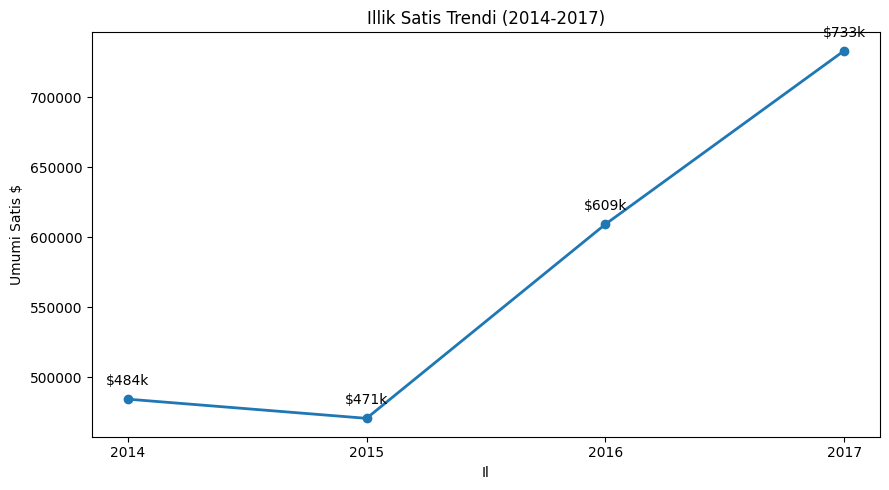

In [52]:
plt.figure(figsize=(9, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', linewidth=2, color='#1f77b4')
for year, sales in yearly_sales.items():
    plt.annotate(f"${sales/1000:.0f}k", (year, sales), textcoords="offset points", xytext=(0, 10), ha='center')
plt.xticks(yearly_sales.index)
plt.xlabel('Il')
plt.ylabel('Umumi Satis $')
plt.title('Illik Satis Trendi (2014-2017)')
plt.tight_layout()
plt.show()

                 Total_Sales  Total_Profit  Profit_Margin_%
Category                                                   
Technology       836154.0330   145454.9481        17.395712
Office Supplies  719047.0320   122490.8008        17.035158
Furniture        741999.7953    18451.2728         2.486695


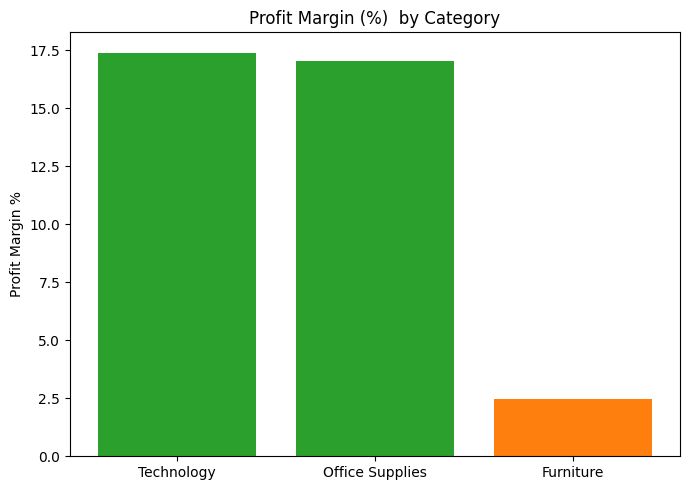

In [53]:
margin_by_category = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
)
margin_by_category['Profit_Margin_%'] = (margin_by_category['Total_Profit'] / margin_by_category['Total_Sales']) * 100
margin_by_category = margin_by_category.sort_values('Profit_Margin_%', ascending=False)
print(margin_by_category)

plt.figure(figsize=(7, 5))
colors_margin = ['#2ca02c' if m > 10 else ('#ff7f0e' if m > 0 else '#d62728') for m in margin_by_category['Profit_Margin_%']]
plt.bar(margin_by_category.index, margin_by_category['Profit_Margin_%'], color=colors_margin)
plt.ylabel('Profit Margin %')
plt.title('Profit Margin (%)  by Category')
plt.tight_layout()
plt.show()

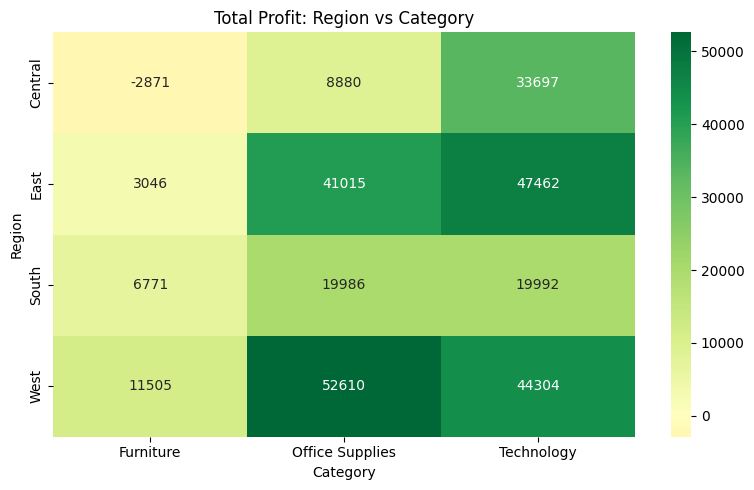

In [54]:
pivot_profit = df.pivot_table(index='Region', columns='Category', values='Profit', aggfunc='sum')
plt.figure(figsize=(8, 5))
sns.heatmap(pivot_profit, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Total Profit: Region vs Category')
plt.tight_layout()
plt.show()